# Notebook 00: Descarga de datos

Este notebook descarga los datos del taller desde Yahoo Finance y los guarda en disco para que el resto de notebooks los carguen rápidamente sin tener que volver a descargar.

**Solo hace falta ejecutarlo una vez al inicio del proyecto** (o si quieres actualizar los datos a fechas más recientes).

## Qué hace este notebook

1. Descarga el cierre ajustado de los 23 tickers del SP500 desde 1945.
2. Calcula los retornos logarítmicos diarios.
3. Guarda los datos en formato Parquet en `data/`.
4. Visualiza los retornos para verificar que todo está correcto.


## 1. Configuración del path

Antes de importar nada de `src/`, añadimos la raíz del proyecto al path de Python. Esto es necesario porque los notebooks se ejecutan desde la carpeta `notebooks/` pero los módulos están en `../src/`.

In [1]:
import sys
from pathlib import Path

# Añadir la raíz del proyecto al PYTHONPATH para poder importar src/
project_root = Path.cwd().parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

print(f"Raíz del proyecto: {project_root}")
print(f"¿Existe la carpeta src/? {(project_root / 'src').exists()}")

Raíz del proyecto: c:\Users\alons\Desktop\B3_T4\taller-redes-neuronales
¿Existe la carpeta src/? True


## 2. Imports

Importamos las funciones que necesitamos. Solo hacen falta:
- `descargar_datos` del módulo `src.data`.
- `plot_returns` del módulo `src.plotting` para visualizar.

In [2]:
import warnings
warnings.simplefilter(action="ignore", category=FutureWarning)

from src.data import descargar_datos, cargar_returns, cargar_precios, TICKERS, START_DATE
from src.plotting import plot_returns

print(f"Tickers configurados ({len(TICKERS)}): {TICKERS}")
print(f"Fecha de inicio: {START_DATE}")

Tickers configurados (23): ['AEP', 'BA', 'CAT', 'CNP', 'CVX', 'DIS', 'DTE', 'ED', 'GD', 'GE', 'HON', 'HPQ', 'IBM', 'IP', 'JNJ', 'KO', 'KR', 'MMM', 'MO', 'MRK', 'MSI', 'PG', 'XOM']
Fecha de inicio: 1945-01-01


## 3. Descarga (o carga desde caché)

La función `descargar_datos` automáticamente:
- Si NO existe el caché en `data/returns.parquet`, descarga de Yahoo Finance.
- Si ya existe, lo carga de disco (mucho más rápido).

Si quieres forzar una redescarga, pasa `force=True`.

In [3]:
returns = descargar_datos(force=False, verbose=True)
print()
print(f"Forma de los retornos: {returns.shape}")
print(f"Rango de fechas: {returns.index.min().date()} a {returns.index.max().date()}")
returns.head()

[descargar_datos] Descargando 23 tickers desde 1945-01-01...


[*********************100%***********************]  23 of 23 completed


[descargar_datos] Guardado en returns.parquet
[descargar_datos] Forma de los retornos: (16192, 23)

Forma de los retornos: (16192, 23)
Rango de fechas: 1962-01-03 a 2026-05-05


Ticker,AEP,BA,CAT,CNP,CVX,DIS,DTE,ED,GD,GE,...,IP,JNJ,KO,KR,MMM,MO,MRK,MSI,PG,XOM
Date,,,,,,,,,,,,,,,,,,,,,
1962-01-03,-0.001823,0.019803,0.009693,-0.009820,-0.002260,0.013333,-0.008265,0.000000,0.032925,-0.010084,...,-0.013746,-0.015670,-0.022531,0.020791,0.007492,-0.018518,-0.042803,-0.002912,-0.010989,0.014742
1962-01-04,-0.014707,-0.009852,0.025398,0.000000,-0.009091,0.000000,-0.008333,-0.003092,0.004040,-0.011894,...,-0.003466,-0.010579,0.007570,-0.004124,0.000000,0.006985,-0.010256,-0.008785,-0.016712,0.002436
1962-01-05,-0.022473,-0.020001,0.009361,-0.024418,-0.025435,0.003308,-0.021143,-0.021909,0.004024,-0.025976,...,0.010364,-0.016089,-0.022876,-0.025106,-0.026467,0.011533,-0.034461,-0.005900,-0.007049,-0.022141
1962-01-08,-0.007603,0.002521,0.006192,-0.011299,-0.004696,-0.003308,0.002134,0.004736,0.015936,-0.001756,...,-0.020835,-0.016349,-0.010335,-0.004245,-0.005764,-0.006904,0.003042,-0.017911,-0.027242,-0.002491
1962-01-09,-0.007663,0.002516,0.009216,0.000000,0.014020,0.019677,0.002130,-0.001576,0.003945,0.005260,...,-0.014134,0.010930,0.018017,-0.021506,0.000000,-0.018647,0.004551,-0.024391,-0.001454,-0.002497


## 4. Verificación rápida

Comprobamos que no hay valores extraños y que el shape es el esperado.

In [4]:
# Estadísticas básicas por activo
returns.describe().T

,count,mean,std,min,25%,50%,75%,max
Ticker,,,,,,,,
AEP,16192.0,0.000312,0.013078,-0.258575,-0.006221,0.000000,0.006920,0.181002
BA,16192.0,0.000436,0.021387,-0.272444,-0.010460,0.000000,0.010969,0.217677
CAT,16192.0,0.000468,0.018671,-0.243622,-0.009175,0.000000,0.010172,0.137350
CNP,16192.0,0.000311,0.017253,-0.548341,-0.007018,0.000000,0.007989,0.488353
CVX,16192.0,0.000398,0.016138,-0.250062,-0.007906,0.000000,0.008659,0.204904
DIS,16192.0,0.000462,0.019817,-0.343821,-0.009569,0.000000,0.010257,0.174755
DTE,16192.0,0.000367,0.012493,-0.149719,-0.006312,0.000000,0.007326,0.145181
ED,16192.0,0.000378,0.012591,-0.384846,-0.005362,0.000000,0.006005,0.165631
GD,16192.0,0.000471,0.018857,-0.156281,-0.008917,0.000000,0.009241,0.182321


In [5]:
# ¿Hay valores nulos?
nulls = returns.isnull().sum()
if nulls.sum() == 0:
    print("OK: No hay valores nulos en los retornos.")
else:
    print("ATENCIÓN: hay valores nulos:")
    print(nulls[nulls > 0])

OK: No hay valores nulos en los retornos.


## 5. Visualización

Plotamos los retornos de los 23 activos para ver que la serie temporal tiene sentido (alta volatilidad concentrada en las crisis: 2000, 2008, 2020).

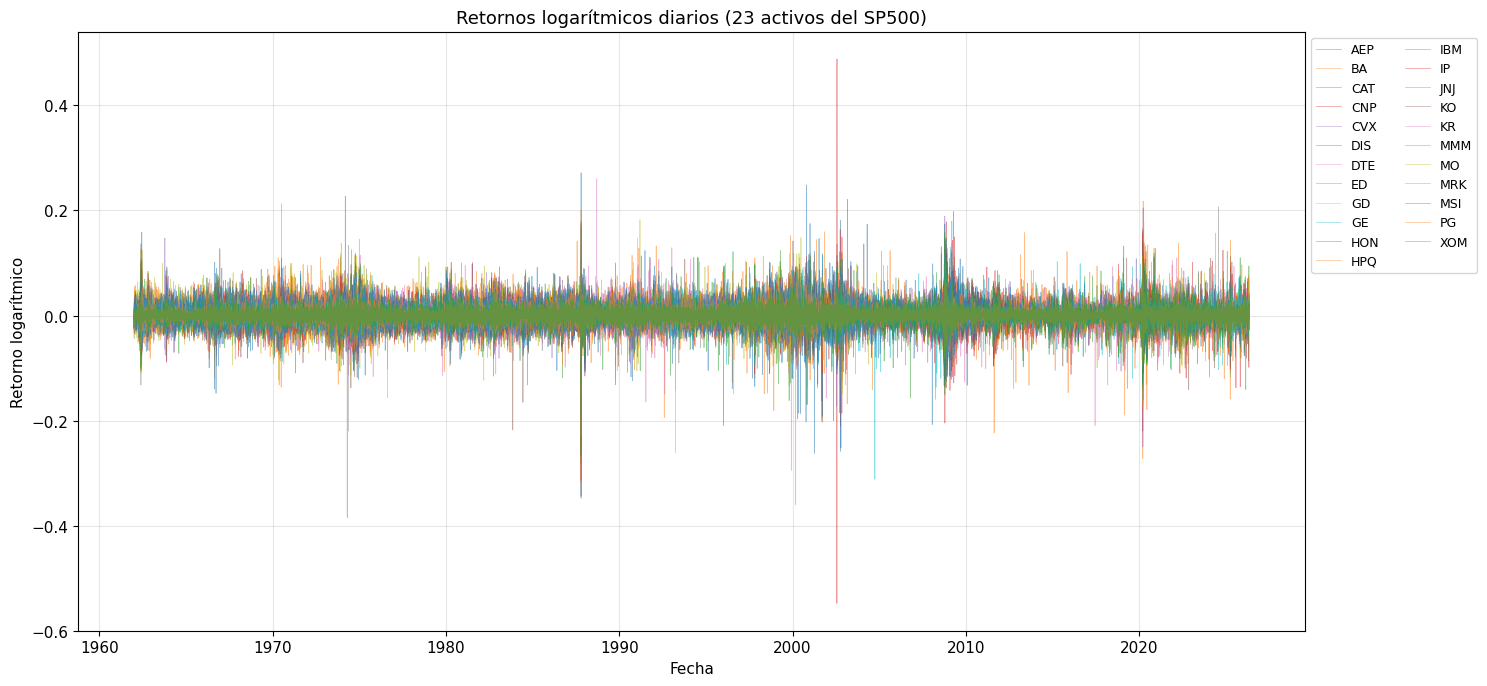

In [6]:
fig, ax = plot_returns(
    returns,
    title=f"Retornos logarítmicos diarios ({returns.shape[1]} activos del SP500)",
    save_path=project_root / "results" / "figures" / "00_returns_completos.png",
)

## 6. Verificación: cargar desde caché

Comprobamos que la función `cargar_returns` funciona, que es la que usaremos en el resto de notebooks (sin volver a descargar).

In [7]:
returns_cached = cargar_returns(verbose=True)
print(f"Forma: {returns_cached.shape}")
print(f"¿Es idéntico a lo descargado? {returns.equals(returns_cached)}")

[cargar_returns] Cargados 16192 días, 23 activos
Forma: (16192, 23)
¿Es idéntico a lo descargado? True


## 7. Comprobar precios también

Por si en algún notebook necesitamos los precios crudos (no los retornos).

In [8]:
precios = cargar_precios(verbose=True)
precios.head()

[cargar_precios] Cargados 16193 días, 23 activos


Ticker,AEP,BA,CAT,CNP,CVX,DIS,DTE,ED,GD,GE,...,IP,JNJ,KO,KR,MMM,MO,MRK,MSI,PG,XOM
Date,,,,,,,,,,,,,,,,,,,,,
1962-01-02,0.894096,0.190931,0.462333,0.284116,0.307970,0.057055,0.386574,0.240809,0.168170,0.617245,...,0.830127,0.060341,0.044744,0.031859,0.554941,0.002384,0.063742,0.613481,0.244460,0.088754
1962-01-03,0.892468,0.194750,0.466836,0.281340,0.307275,0.057821,0.383392,0.240809,0.173799,0.611052,...,0.818794,0.059403,0.043747,0.032528,0.559114,0.002341,0.061072,0.611697,0.241788,0.090072
1962-01-04,0.879439,0.192840,0.478844,0.281340,0.304494,0.057821,0.380211,0.240066,0.174503,0.603827,...,0.815961,0.058778,0.044080,0.032394,0.559114,0.002357,0.060448,0.606347,0.237781,0.090291
1962-01-05,0.859895,0.189022,0.483348,0.274553,0.296847,0.058012,0.372256,0.234863,0.175207,0.588343,...,0.824462,0.057840,0.043083,0.031591,0.544511,0.002384,0.058401,0.602780,0.236111,0.088314
1962-01-08,0.853382,0.189499,0.486350,0.271468,0.295456,0.057821,0.373052,0.235978,0.178021,0.587311,...,0.807462,0.056902,0.042640,0.031457,0.541381,0.002368,0.058579,0.592080,0.229766,0.088095


## Resumen

Si todas las celdas anteriores se ejecutaron sin error, ya tienes los datos guardados en:

- `data/returns.parquet`: retornos logarítmicos diarios.
- `data/precios_close.parquet`: precios de cierre ajustados.
- `results/figures/00_returns_completos.png`: gráfica de los retornos.

**Siguiente paso**: ejecutar el notebook `01_baselines.ipynb` para entrenar los baselines no neuronales (regresión lineal, persistencia, etc.).